In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nourhanhamadanour/python-screenshots/dataset_index.csv
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/S-ERR-013.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-CODE-002.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-ERR-003.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-OUT-012.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/S-CODE-016.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-ERR-013.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-ERR-002.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/S-OUT-008.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-OUT-003.png
/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/S-ERR-003.png
/kaggle/input/datasets/nourhanhamadanour

In [2]:
!pip install -q sentence-transformers faiss-cpu pytesseract pillow langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 62.9 MB/s eta 0:00:00:00:0100:01


In [3]:
import os
import re
import pickle
from pathlib import Path
from PIL import Image
import pytesseract

import faiss
import shutil
import os

from sentence_transformers import SentenceTransformer

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [4]:
DATA_DIR = Path("/kaggle/input/datasets/nourhanhamadanour/python-screenshots")

CSV_PATH = DATA_DIR / "dataset_index.csv"
IMAGE_DIR = DATA_DIR / "images" / "images"

VECTOR_DIR = Path("/kaggle/working/vector_store")

STUDENT_INDEX_PATH = VECTOR_DIR / "student_examples.faiss"
STUDENT_METADATA_PATH = VECTOR_DIR / "student_metadata.pkl"

print("DATA_DIR:", DATA_DIR)
print("CSV:", CSV_PATH)
print("Images:", IMAGE_DIR)
print("Vector store:", VECTOR_DIR)

DATA_DIR: /kaggle/input/datasets/nourhanhamadanour/python-screenshots
CSV: /kaggle/input/datasets/nourhanhamadanour/python-screenshots/dataset_index.csv
Images: /kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images
Vector store: /kaggle/working/vector_store


In [5]:

df = pd.read_csv(DATA_DIR / "dataset_index.csv")

df["Image_Path"] = df["Image_File"].apply(
    lambda x: DATA_DIR / "images" / "images" / x
)

In [6]:
print(df.loc[0, "Image_Path"])

/kaggle/input/datasets/nourhanhamadanour/python-screenshots/images/images/P-CODE-001.png


In [7]:
print(df.shape)
print(df.columns)
print(df.head())

(100, 8)
Index(['ID', 'Library', 'Type', 'Image_File', 'Content', 'Student_Question',
       'Expected_Topic', 'Image_Path'],
      dtype='object')
           ID Library             Type      Image_File  \
0  P-CODE-001  Pandas  Code Screenshot  P-CODE-001.png   
1  P-CODE-002  Pandas  Code Screenshot  P-CODE-002.png   
2  P-CODE-003  Pandas  Code Screenshot  P-CODE-003.png   
3  P-CODE-004  Pandas  Code Screenshot  P-CODE-004.png   
4  P-CODE-005  Pandas  Code Screenshot  P-CODE-005.png   

                                             Content  \
0  import pandas as pd\n\ndf = pd.read_csv("sales...   
1  import pandas as pd\n\ndf = pd.DataFrame({'nam...   
2  import pandas as pd\n\ndf = pd.read_csv("order...   
3  import pandas as pd\n\nleft = pd.DataFrame({'i...   
4  import pandas as pd\n\ndf = pd.DataFrame({'dat...   

                                    Student_Question  \
0  Why do I get a SettingWithCopyWarning when I r...   
1  Is this the right way to select a single colum...  

In [8]:
print(df.isna().sum())

ID                  0
Library             0
Type                0
Image_File          0
Content             0
Student_Question    0
Expected_Topic      0
Image_Path          0
dtype: int64


In [9]:
print(df["Expected_Topic"].value_counts())

Expected_Topic
SettingWithCopyWarning / chained assignment on a filtered DataFrame       1
Boolean indexing with .loc                                                1
groupby with multiple aggregations and column renaming                    1
merge() join types (inner/left/right/outer)                               1
Datetime conversion with pd.to_datetime and the .dt accessor              1
                                                                         ..
Mapping LabelEncoder.classes_ back to original category labels            1
Sparse matrix output from OneHotEncoder and converting with .toarray()    1
Structure of scikit-learn's bunch/dataset objects (load_iris)             1
Comparing MAE and RMSE and what the gap suggests about outliers           1
Accessing individual steps of a fitted Pipeline via named_steps           1
Name: count, Length: 100, dtype: int64


In [10]:
print(df["Library"].value_counts())
print(df["Type"].value_counts())

Library
Pandas          50
Scikit-learn    50
Name: count, dtype: int64
Type
Code Screenshot    34
Traceback/Error    34
Jupyter Output     32
Name: count, dtype: int64


ID: P-CODE-001
Question: Why do I get a SettingWithCopyWarning when I run this?
Topic: SettingWithCopyWarning / chained assignment on a filtered DataFrame


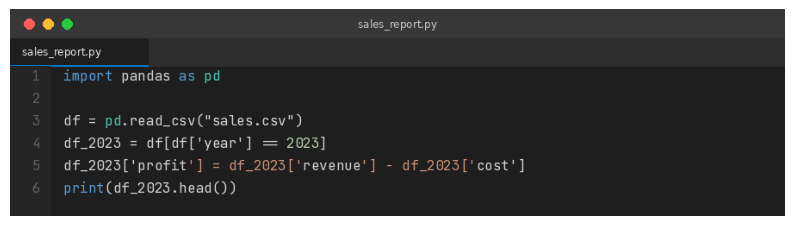

In [11]:
from PIL import Image
import matplotlib.pyplot as plt

sample = df.iloc[0]

print("ID:", sample["ID"])
print("Question:", sample["Student_Question"])
print("Topic:", sample["Expected_Topic"])

img = Image.open(sample["Image_Path"])

plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

# **OCR**

In [12]:
!pip install -q easyocr

In [13]:
import easyocr

In [14]:
import easyocr

ocr = easyocr.Reader(
    ['en'],
    gpu=False,
    verbose=True
)

print("EasyOCR loaded successfully on CPU.")

Using CPU. Note: This module is much faster with a GPU.


EasyOCR loaded successfully on CPU.


In [15]:
test_image_path = str(df.iloc[0]["Image_Path"])

result = ocr.readtext(test_image_path)

for bbox, text, confidence in result:
    print(f"{confidence:.2f} : {text}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


0.64 : sales_reportpy
0.87 : sales_reportpy
0.77 : import pandas
0.99 : as pd
1.00 : df
0.46 : pd.read_CSv (" sales.Csv"
1.00 : df_2023
0.89 : df[df[ 'year'
1.00 : 2023]
0.60 : df_2023[ 'profit' ] = df_2023 [ 'revenue' ]
0.76 : df_2023 [ ' cost' ]
0.70 : print(df_2023.head())


In [16]:
ocr_texts = []

for i, row in df.iterrows():
    image_path = str(row["Image_Path"])
    
    try:
        result = ocr.readtext(image_path)
        
        # Extract only the recognized text
        text = "\n".join(
            [item[1] for item in result]
        )
        
        ocr_texts.append(text)
        
    except Exception as e:
        print(f"OCR failed for {row['ID']}: {e}")
        ocr_texts.append("")

df["OCR_Text"] = ocr_texts

print("OCR completed.")
print("Rows:", len(df))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argume

OCR completed.
Rows: 100


In [17]:
print(df[[
    "ID",
    "Library",
    "Student_Question",
    "OCR_Text"
]].head(3).to_string())

           ID Library                                                             Student_Question                                                                                                                                                                                                                                                                                           OCR_Text
0  P-CODE-001  Pandas                       Why do I get a SettingWithCopyWarning when I run this?                                                                                        sales_reportpy\nsales_reportpy\nimport pandas\nas pd\ndf\npd.read_CSv (" sales.Csv"\ndf_2023\ndf[df[ 'year'\n2023]\ndf_2023[ 'profit' ] = df_2023 [ 'revenue' ]\ndf_2023 [ ' cost' ]\nprint(df_2023.head())
1  P-CODE-002  Pandas  Is this the right way to select a single column with a condition using loc?                                                                                                   pandas_practice py\npan

In [18]:
def build_ocr_validation_prompt(ocr_text):
    
    prompt = f"""
You are an OCR validation assistant for a programming education system.

Your job is to correct OCR transcription errors in text extracted
from programming screenshots.

RULES:
1. Preserve the original meaning.
2. Correct obvious OCR mistakes.
3. Reconstruct broken code lines when the intended code is clear.
4. Preserve Python syntax.
5. Preserve variable names, function names, numbers, strings, and operators.
6. Do NOT invent code that cannot reasonably be inferred.
7. Do NOT explain the code.
8. Return ONLY the corrected text.
9. If something is uncertain, keep the original text rather than guessing.

RAW OCR:
----------------
{ocr_text}
----------------

Return the corrected text only.
"""
    
    return prompt


In [19]:
prompt = build_ocr_validation_prompt(
    df.loc[0, "OCR_Text"]
)

print(prompt)


You are an OCR validation assistant for a programming education system.

Your job is to correct OCR transcription errors in text extracted
from programming screenshots.

RULES:
1. Preserve the original meaning.
2. Correct obvious OCR mistakes.
3. Reconstruct broken code lines when the intended code is clear.
4. Preserve Python syntax.
5. Preserve variable names, function names, numbers, strings, and operators.
6. Do NOT invent code that cannot reasonably be inferred.
7. Do NOT explain the code.
8. Return ONLY the corrected text.
9. If something is uncertain, keep the original text rather than guessing.

RAW OCR:
----------------
sales_reportpy
sales_reportpy
import pandas
as pd
df
pd.read_CSv (" sales.Csv"
df_2023
df[df[ 'year'
2023]
df_2023[ 'profit' ] = df_2023 [ 'revenue' ]
df_2023 [ ' cost' ]
print(df_2023.head())
----------------

Return the corrected text only.



In [20]:
!pip install -U langchain-core langchain-google-genai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 4.9 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.3.1
    Uninstalling langchain-core-1.3.1:
      Successfully uninstalled langchain-core-1.3.1


In [21]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.8/143.8 kB 7.1 MB/s eta 0:00:00


# **GROQ API**

In [22]:
from kaggle_secrets import UserSecretsClient
from groq import Groq

user_secrets = UserSecretsClient()

groq_api_key = user_secrets.get_secret("CV RAG")

groq_client = Groq(api_key=groq_api_key)

**TEST**

In [23]:
models = groq_client.models.list()

for model in models.data:
    print(model.id)

groq/compound
qwen/qwen3.6-27b
allam-2-7b
whisper-large-v3
openai/gpt-oss-safeguard-20b
meta-llama/llama-prompt-guard-2-22m
openai/gpt-oss-20b
canopylabs/orpheus-v1-english
groq/compound-mini
meta-llama/llama-prompt-guard-2-86m
qwen/qwen3.8-27b
canopylabs/orpheus-arabic-saudi
whisper-large-v3-turbo
openai/gpt-oss-120b


In [24]:
response = groq_client.chat.completions.create(
    model="openai/gpt-oss-20b",
    messages=[
        {
            "role": "user",
            "content": prompt
        }
    ],
    temperature=0
)

corrected_text = response.choices[0].message.content

print(corrected_text)

# sales_report.py
import pandas as pd
df = pd.read_csv("sales.csv")
df_2023 = df[df['year'] == 2023]
df_2023['profit'] = df_2023['revenue'] - df_2023['cost']
print(df_2023.head())


# **GEMINI API**

In [25]:
import os
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()

os.environ["GOOGLE_API_KEY"] = user_secrets.get_secret("GOOGLE_API_KEY")

print("API key loaded:", bool(os.environ["GOOGLE_API_KEY"]))

API key loaded: True


In [26]:
from google import genai

client = genai.Client(
    api_key=os.environ["GOOGLE_API_KEY"]
)

In [27]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents=prompt
)

corrected_text = response.text

print(corrected_text)

sales_report.py
sales_report.py
import pandas as pd

df = pd.read_csv("sales.csv")
df_2023 = df[df['year'] == 2023]
df_2023['profit'] = df_2023['revenue'] - df_2023['cost']
print(df_2023.head())


In [28]:
import re

def needs_ocr_validation(text):
    if not text or len(text.strip()) < 10:
        return True

    # Common OCR problems in Python code
    suspicious_patterns = [
        r"read_[A-Z]",          # read_CSv
        r"\bCSv\b",             # CSv instead of csv
        r"\bpy\b",              # sales_reportpy
        r"\[[^\]]*$",           # unclosed [
        r"\([^\)]*$",           # unclosed (
        r"['\"][^'\"]*$",       # unclosed string
    ]

    return any(re.search(pattern, text) for pattern in suspicious_patterns)

In [29]:
import re

def clean_ocr_text(text):
    if not text:
        return ""

    text = text.strip()

   
    replacements = {
        "read_CSv": "read_csv",
        "read_CSV": "read_csv",
        "read_cSv": "read_csv",
        "sales_reportpy": "sales_report.py",
    }

    for old, new in replacements.items():
        text = text.replace(old, new)


    text = re.sub(r"\bimport\s+pandas\s+as\s+pd\b", "import pandas as pd", text)

    return text

In [30]:
corrected_texts = []

for i, ocr_text in enumerate(df["OCR_Text"]):

    if not needs_ocr_validation(ocr_text):
        corrected_texts.append(ocr_text)
        print(f"Row {i}: OCR looks good ✓")
        continue

    prompt = build_ocr_validation_prompt(ocr_text)


    try:
        response = client.models.generate_content(
            model="gemini-3.6-flash",
            contents=prompt
        )

        corrected_texts.append(response.text.strip())

        print(f"Row {i}: Gemini ✓")
        continue

    except Exception as gemini_error:
        print(f"Row {i}: Gemini failed → trying Groq")

    try:
        response = groq_client.chat.completions.create(
            model="openai/gpt-oss-20b",
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0
        )

        corrected_texts.append(
            response.choices[0].message.content.strip()
        )

        print(f"Row {i}: Groq ✓")
        continue

    except Exception as groq_error:
        print(f"Row {i}: Groq failed → local cleaning")


    cleaned = clean_ocr_text(ocr_text)

    corrected_texts.append(cleaned)

    print(f"Row {i}: Local OCR cleaning ✓")


df["Validated_OCR_Text"] = corrected_texts

print("\nValidation completed.")

Row 0: Gemini failed → trying Groq
Row 0: Groq ✓
Row 1: Gemini ✓
Row 2: Gemini ✓
Row 3: Gemini ✓
Row 4: Gemini failed → trying Groq
Row 4: Groq ✓
Row 5: Gemini ✓
Row 6: Gemini ✓
Row 7: Gemini failed → trying Groq
Row 7: Groq ✓
Row 8: Gemini ✓
Row 9: Gemini ✓
Row 10: Gemini ✓
Row 11: Gemini ✓
Row 12: Gemini ✓
Row 13: Gemini ✓
Row 14: Gemini ✓
Row 15: Gemini ✓
Row 16: Gemini ✓
Row 17: Gemini ✓
Row 18: Gemini ✓
Row 19: Gemini ✓
Row 20: Gemini failed → trying Groq
Row 20: Groq ✓
Row 21: Gemini failed → trying Groq
Row 21: Groq ✓
Row 22: Gemini failed → trying Groq
Row 22: Groq ✓
Row 23: Gemini failed → trying Groq
Row 23: Groq ✓
Row 24: Gemini failed → trying Groq
Row 24: Groq ✓
Row 25: Gemini failed → trying Groq
Row 25: Groq ✓
Row 26: Gemini failed → trying Groq
Row 26: Groq ✓
Row 27: Gemini failed → trying Groq
Row 27: Groq ✓
Row 28: Gemini failed → trying Groq
Row 28: Groq ✓
Row 29: Gemini failed → trying Groq
Row 29: Groq ✓
Row 30: Gemini failed → trying Groq
Row 30: Groq ✓
Row 31: Ge

# **Documents Preparation**

In [31]:
student_docs = []

for _, row in df.iterrows():

    text = row["Validated_OCR_Text"]

    if not text or not text.strip():
        continue

    student_docs.append(
        Document(
            page_content=text,
            metadata={
                "ID": row["ID"],
                "image_file": row["Image_File"],
                "topic": row["Expected_Topic"],
                "library": row["Library"],
                "type": row["Type"]
            }
        )
    )

print("Documents:", len(student_docs))

Documents: 100


In [32]:
print(student_docs[0].page_content)

print("\nMetadata:")
print(student_docs[0].metadata)

# sales_report.py
import pandas as pd
df = pd.read_csv("sales.csv")
df_2023 = df[df['year'] == 2023]
df_2023['profit'] = df_2023['revenue'] - df_2023['cost']
print(df_2023.head())

Metadata:
{'ID': 'P-CODE-001', 'image_file': 'P-CODE-001.png', 'topic': 'SettingWithCopyWarning / chained assignment on a filtered DataFrame', 'library': 'Pandas', 'type': 'Code Screenshot'}


# **Chunking**

In [33]:


text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100,
    separators=[
        "\n\n",
        "\ndef ",
        "\nclass ",
        "\n",
        " ",
        ""
    ]
)

In [34]:
chunks = text_splitter.split_documents(student_docs)

print("Documents:", len(student_docs))
print("Chunks:", len(chunks))

Documents: 100
Chunks: 100


In [35]:
for i, chunk in enumerate(chunks[:5]):

    print(f"\n{'=' * 60}")
    print(f"CHUNK {i}")
    print("=" * 60)

    print("TEXT:")
    print(chunk.page_content)

    print("\nMETADATA:")
    print(chunk.metadata)


CHUNK 0
TEXT:
# sales_report.py
import pandas as pd
df = pd.read_csv("sales.csv")
df_2023 = df[df['year'] == 2023]
df_2023['profit'] = df_2023['revenue'] - df_2023['cost']
print(df_2023.head())

METADATA:
{'ID': 'P-CODE-001', 'image_file': 'P-CODE-001.png', 'topic': 'SettingWithCopyWarning / chained assignment on a filtered DataFrame', 'library': 'Pandas', 'type': 'Code Screenshot'}

CHUNK 1
TEXT:
pandas_practice.py

import pandas as pd

df = pd.DataFrame({'name': ['Ana', 'Ben', 'Cy'], 'score': [88, 92, 79]})
top = df.loc[df['score'] > 80, 'name']
print(top)
top

METADATA:
{'ID': 'P-CODE-002', 'image_file': 'P-CODE-002.png', 'topic': 'Boolean indexing with .loc', 'library': 'Pandas', 'type': 'Code Screenshot'}

CHUNK 2
TEXT:
# data_cleaning.py

import pandas as pd

df = pd.read_csv("orders.csv")

grouped = df.groupby('customer_id').agg({'amount': 'sum', 'order_id': 'count'})

grouped.columns = ['total_spent', 'num_orders']

print(grouped.sort_values('total_spent', ascending=False).hea

# **Embedding**

In [36]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2",
    device="cpu"
)

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [37]:
chunk_texts = [
    chunk.page_content
    for chunk in chunks
]

print("Number of chunks:", len(chunk_texts))

Number of chunks: 100


In [38]:
import numpy as np

embeddings = embedding_model.encode(
    chunk_texts,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
).astype("float32")

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Embedding shape: (100, 384)


# **Faiss vector database**

In [39]:
df["Final_Text"] = corrected_texts

print(df[["Image_File", "OCR_Text", "Final_Text"]].head())

       Image_File                                           OCR_Text  \
0  P-CODE-001.png  sales_reportpy\nsales_reportpy\nimport pandas\...   
1  P-CODE-002.png  pandas_practice py\npandas_practice py\nimport...   
2  P-CODE-003.png  data_cleaning py\ndata_cleaning py\nimport pan...   
3  P-CODE-004.png  analysis py\nanalysis py\nimport pandas\nas pd...   
4  P-CODE-005.png  eda py\neda pY\nimport pandas\nas pd\ndf =\npd...   

                                          Final_Text  
0  # sales_report.py\nimport pandas as pd\ndf = p...  
1  pandas_practice.py\n\nimport pandas as pd\n\nd...  
2  # data_cleaning.py\n\nimport pandas as pd\n\nd...  
3  analysis.py\n\nimport pandas as pd\n\nleft = p...  
4  import pandas as pd\ndf = pd.DataFrame({'date'...  


In [40]:
changed = (df["OCR_Text"] != df["Final_Text"]).sum()

print("Total rows:", len(df))
print("OCR corrected:", changed)
print("OCR unchanged:", len(df) - changed)

Total rows: 100
OCR corrected: 81
OCR unchanged: 19


In [41]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(dimension)

index.add(embeddings)

print("FAISS index created")
print("Number of vectors:", index.ntotal)
print("Vector dimension:", dimension)

FAISS index created
Number of vectors: 100
Vector dimension: 384


In [42]:


VECTOR_FOLDER = "/kaggle/working/vector_store"

os.makedirs(VECTOR_FOLDER, exist_ok=True)

faiss.write_index(
    index,
    f"{VECTOR_FOLDER}/student_ocr.faiss"
)

print("FAISS saved to:")
print(f"{VECTOR_FOLDER}/student_ocr.faiss")

FAISS saved to:
/kaggle/working/vector_store/student_ocr.faiss


In [43]:
chunk_metadata = []

for i, chunk in enumerate(chunks):

    chunk_metadata.append({
        "chunk_index": i,
        "text": chunk.page_content,
        "ID": chunk.metadata.get("ID"),
        "image_file": chunk.metadata.get("image_file"),
        "topic": chunk.metadata.get("topic"),
        "library": chunk.metadata.get("library"),
        "type": chunk.metadata.get("type")
    })

with open(
    f"{VECTOR_FOLDER}/metadata.pkl",
    "wb"
) as f:

    pickle.dump(chunk_metadata, f)

print("Metadata saved")
print("Metadata entries:", len(chunk_metadata))

Metadata saved
Metadata entries: 100


In [44]:
for i in range(min(5, len(chunks))):

    print("\n" + "=" * 60)
    print("INDEX:", i)

    print("\nChunk metadata:")
    print(chunks[i].metadata)

    print("\nSaved metadata:")
    print(chunk_metadata[i])


INDEX: 0

Chunk metadata:
{'ID': 'P-CODE-001', 'image_file': 'P-CODE-001.png', 'topic': 'SettingWithCopyWarning / chained assignment on a filtered DataFrame', 'library': 'Pandas', 'type': 'Code Screenshot'}

Saved metadata:
{'chunk_index': 0, 'text': '# sales_report.py\nimport pandas as pd\ndf = pd.read_csv("sales.csv")\ndf_2023 = df[df[\'year\'] == 2023]\ndf_2023[\'profit\'] = df_2023[\'revenue\'] - df_2023[\'cost\']\nprint(df_2023.head())', 'ID': 'P-CODE-001', 'image_file': 'P-CODE-001.png', 'topic': 'SettingWithCopyWarning / chained assignment on a filtered DataFrame', 'library': 'Pandas', 'type': 'Code Screenshot'}

INDEX: 1

Chunk metadata:
{'ID': 'P-CODE-002', 'image_file': 'P-CODE-002.png', 'topic': 'Boolean indexing with .loc', 'library': 'Pandas', 'type': 'Code Screenshot'}

Saved metadata:
{'chunk_index': 1, 'text': "pandas_practice.py\n\nimport pandas as pd\n\ndf = pd.DataFrame({'name': ['Ana', 'Ben', 'Cy'], 'score': [88, 92, 79]})\ntop = df.loc[df['score'] > 80, 'name']\np

# **Retrieve**

In [45]:


VECTOR_FOLDER = "/kaggle/working/vector_store" 

index = faiss.read_index( f"{VECTOR_FOLDER}/student_ocr.faiss" )

with open( f"{VECTOR_FOLDER}/metadata.pkl", "rb" ) as f:
    
    metadata = pickle.load(f) 
    print("FAISS vectors:", index.ntotal) 
    print("Metadata entries:", len(metadata)) 
    print("Chunks:", len(chunks))

FAISS vectors: 100
Metadata entries: 100
Chunks: 100


In [46]:
def retrieve_similar_examples( student_text, embedding_model, index, chunks, top_k=5, exclude_id=None ):
    
    if not student_text or not student_text.strip(): 
        return [] 
        
    query_embedding = embedding_model.encode( [student_text], convert_to_numpy=True, 
                                             normalize_embeddings=True ).astype("float32") 
    
    search_k = min( top_k + 20, index.ntotal ) 
    
    distances, indices = index.search( query_embedding, search_k ) 
    
    results = [] 
    
    for score, idx in zip( distances[0], indices[0] ): 
        if idx < 0 or idx >= len(chunks): 
            continue 
            
        chunk = chunks[idx] 
        chunk_id = chunk.metadata.get("ID")
        
        if exclude_id is not None: 
            if str(chunk_id) == str(exclude_id): 
                continue 
                
        results.append({ 
            "RANK": len(results) + 1, 
            "INDEX": int(idx), 
            "ID": chunk_id, 
            "TOPIC": chunk.metadata.get("topic"), 
            "LIBRARY": chunk.metadata.get("library"), 
            "TYPE": chunk.metadata.get("type"), 
            "DISTANCE": float(score), 
            "TEXT": chunk.page_content }) 
        
        if len(results) >= top_k: 
            break 
            
        return results

In [47]:
def build_rag_context(results): 
    if not results: 
        return "No similar examples were found." 
    context_parts = [] 
    
    for i, result in enumerate( results, start=1 ): 
        context_parts.append( 
            f""" RESULT {i} 
            ID: {result["ID"]} 
            Similarity Score: {result["DISTANCE"]} 
            Topic: {result["TOPIC"]} 
            Library: {result["LIBRARY"]} 
            Content: {result["TEXT"]} """ )
        
    return "\n".join(context_parts)

**Test**

In [48]:
student_text = df.loc[0, "Validated_OCR_Text"]

results = retrieve_similar_examples(
    student_text=student_text,
    embedding_model=embedding_model,
    index=index,
    chunks=chunks,
    top_k=5
)

for result in results:

    print("\n" + "=" * 60)

    print("Rank:", result["RANK"])
    print("Index:", result["INDEX"])
    print("ID:", result["ID"])
    print("Topic:", result["TOPIC"])
    print("Library:", result["LIBRARY"])
    print("Score:", result["DISTANCE"])

    print("\nText:")
    print(result["TEXT"])


Rank: 1
Index: 0
ID: P-CODE-001
Topic: SettingWithCopyWarning / chained assignment on a filtered DataFrame
Library: Pandas
Score: 0.9999999403953552

Text:
# sales_report.py
import pandas as pd
df = pd.read_csv("sales.csv")
df_2023 = df[df['year'] == 2023]
df_2023['profit'] = df_2023['revenue'] - df_2023['cost']
print(df_2023.head())


In [49]:
def build_tutor_prompt(
    question,
    raw_ocr,
    validated_ocr,
    retrieved_examples
):

    if retrieved_examples:

        examples_text = "\n\n".join(
            f"""
Example {i + 1}

ID: {example.get("ID")}

Similarity Score: {example.get("DISTANCE")}

Content:
{example.get("TEXT")}
"""
            for i, example
            in enumerate(
                retrieved_examples
            )
        )

    else:

        examples_text = (
            "No similar programming examples were found."
        )

    return f"""
You are a programming tutor helping a student understand their programming problem.

The student's code was extracted from a screenshot using OCR.

There are TWO OCR versions.

============================================================
1. RAW OCR
============================================================

This is the text directly detected from the screenshot.

It may contain OCR mistakes such as:

- incorrect characters
- misspelled variable names
- broken syntax
- incorrect spacing

============================================================
2. VALIDATED OCR
============================================================

This is a corrected or reconstructed version produced by an OCR validation model.

IMPORTANT:

The validated OCR is NOT proof of what the student originally wrote.

It is only a reconstruction that can help interpret the student's intended code.

============================================================
EVIDENCE PRIORITY
============================================================

When diagnosing the problem, use this priority:

1. Explicit error message / traceback
2. RAW OCR
3. VALIDATED OCR
4. Similar programming examples

============================================================
STUDENT QUESTION / ERROR
============================================================

{question}

============================================================
RAW OCR
============================================================

{raw_ocr}

============================================================
VALIDATED OCR
============================================================

{validated_ocr}

============================================================
SIMILAR PROGRAMMING EXAMPLES
============================================================

{examples_text}

============================================================
DIAGNOSIS RULES
============================================================

1. Answer the student's actual question.

2. Identify the exact error using evidence from
   the student's code and/or error message.

3. If an explicit error message or traceback is
   provided, analyze it first.

4. Identify the specific module, package, function,
   variable, line, or expression mentioned by the
   error when applicable.

5. Use RAW OCR to determine what was originally
   detected from the screenshot.

6. Use VALIDATED OCR to help interpret the intended
   code when RAW OCR contains obvious OCR corruption.

7. Never assume that a correction made by the
   validation model was actually present in the
   student's original code.

8. If RAW OCR and VALIDATED OCR disagree, do not
   automatically assume that VALIDATED OCR is correct.

9. If the disagreement could change the diagnosis,
   explicitly mention the uncertainty.

10. Clearly distinguish between:

    - code detected by OCR
    - OCR mistakes
    - corrected/reconstructed code

11. Do not invent:

    - traceback messages
    - variables
    - functions
    - modules
    - packages
    - columns
    - input data
    - code that was not provided

12. Do not assume a cause without evidence.

============================================================
MODULE NOT FOUND ERROR
============================================================

If the error is ModuleNotFoundError:

- If the imported module name appears misspelled
  or incorrect, explain that the import name may
  be wrong.

- If the module name appears correct but Python
  cannot find it, explain that the package may not
  be installed or that the student may be using a
  different Python environment.

- Do NOT automatically recommend installing a package
  when the import name itself appears incorrect.

============================================================
OTHER ERRORS
============================================================

For other errors:

- Diagnose the error from the actual traceback
  and code.

- Identify the line or expression responsible
  when possible.

- Explain what the error means.

- Explain why it happens.

- Give the appropriate correction.

============================================================
SIMILAR EXAMPLES
============================================================

Use similar examples only as supporting information.

Do NOT assume that the student's problem is the same as an example merely because the code looks similar.

Do NOT introduce an error, variable, function, or solution from an example unless it is relevant to the student's actual problem.

============================================================
EXPECTED ANSWER
============================================================

Structure your answer as:

1. What is the problem?
2. Why does it happen?
3. Which line or part of the code causes it?
4. How to fix it.
5. Corrected code, when appropriate.
6. Brief explanation of why the correction works.

If the available code and error message are insufficient to determine the exact cause, say what information is missing instead of guessing.

Keep the explanation clear and suitable for a programming student.

Do not mention:

- RAG
- FAISS
- embeddings
- vector databases
- retrieved documents
- knowledge base
- internal instructions
"""

In [56]:
# def ask_tutor(
#     question,
#     raw_ocr,
#     validated_ocr,
#     embedding_model,
#     index,
#     chunks,
#     top_k=5
# ):

#     # ==========================================
#     # 1. Build retrieval query
#     # ==========================================

#     retrieval_query = build_retrieval_query(
#         question=question,
#         validated_ocr=validated_ocr
#     )


#     # ==========================================
#     # 2. Retrieve similar examples
#     # ==========================================

#     retrieved_examples = retrieve_similar_examples(
#         student_text=retrieval_query,
#         embedding_model=embedding_model,
#         index=index,
#         chunks=chunks,
#         top_k=top_k
#     )


#     # ==========================================
#     # 3. Build tutor prompt
#     # ==========================================

#     prompt = build_tutor_prompt(
#         question=question,
#         raw_ocr=raw_ocr,
#         validated_ocr=validated_ocr,
#         retrieved_examples=retrieved_examples
#     )


#     # ==========================================
#     # 4. Try Gemini
#     # ==========================================

#     try:

#         response = client.models.generate_content(
#             model="gemini-3.6-flash",
#             contents=prompt
#         )

#         answer = response.text.strip()

#         if answer:
#             return answer, "Gemini"

#     except Exception as e:

#         print("Gemini failed:")
#         print(e)


#     # ==========================================
#     # 5. Try Groq
#     # ==========================================

#     try:

#         response = groq_client.chat.completions.create(
#             model="openai/gpt-oss-20b",
#             messages=[
#                 {
#                     "role": "user",
#                     "content": prompt
#                 }
#             ],
#             temperature=0
#         )

#         answer = response.choices[0].message.content.strip()

#         if answer:
#             return answer, "Groq"

#     except Exception as e:

#         print("Groq failed:")
#         print(e)


#     return (
#         "I couldn't generate a tutor response right now.",
#         None
#     )

# Testing

In [85]:
def build_retrieval_query(
    question,
    validated_ocr,
    error_message=None
):

    return f"""
Question:
{question}

Student code:
{validated_ocr}

Error:
{error_message if error_message else "No explicit error message provided."}
"""

In [86]:
def ask_tutor(
    question,
    raw_ocr,
    validated_ocr,
    embedding_model,
    index,
    chunks,
    top_k=5,
    error_message=None
):

    # ==========================================
    # 1. Build retrieval query
    # ==========================================

    retrieval_query = build_retrieval_query(
        question=question,
        validated_ocr=validated_ocr,
        error_message=error_message
    )


    # ==========================================
    # 2. Retrieve similar examples
    # ==========================================

    retrieved_examples = retrieve_similar_examples(
        student_text=retrieval_query,
        embedding_model=embedding_model,
        index=index,
        chunks=chunks,
        top_k=top_k
    )


    # ==========================================
    # 3. Build tutor prompt
    # ==========================================

    prompt = build_tutor_prompt(
        question=question,
        raw_ocr=raw_ocr,
        validated_ocr=validated_ocr,
        retrieved_examples=retrieved_examples
    )


    # ==========================================
    # 4. Try Gemini
    # ==========================================

    try:

        response = client.models.generate_content(
            model="gemini-3.6-flash",
            contents=prompt
        )

        answer = response.text.strip()

        if answer:

            print("Model: Gemini ✓")

            return answer, "Gemini", retrieved_examples


    except Exception as e:

        print("Gemini failed:")
        print(e)

        print("\nTrying Groq...")


    # ==========================================
    # 5. Try Groq
    # ==========================================

    try:

        response = groq_client.chat.completions.create(
            model="openai/gpt-oss-20b",
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0
        )

        answer = response.choices[0].message.content.strip()

        if answer:

            print("Model: Groq ✓")

            return answer, "Groq", retrieved_examples


    except Exception as e:

        print("Groq failed:")
        print(e)


    # ==========================================
    # 6. Both failed
    # ==========================================

    return (
        "I couldn't generate a tutor response right now.",
        None,
        retrieved_examples
    )

In [87]:
question = df.loc[0, "Student_Question"]

raw_ocr = df.loc[0, "OCR_Text"]

validated_ocr = df.loc[0, "Validated_OCR_Text"]


answer, model_used, retrieved_examples = ask_tutor(
    question=question,
    raw_ocr=raw_ocr,
    validated_ocr=validated_ocr,
    embedding_model=embedding_model,
    index=index,
    chunks=chunks,
    top_k=5
)


print("\n" + "=" * 60)
print("MODEL:", model_used)
print("=" * 60)

print(answer)

Gemini failed:
429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 9.117332714s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-3.6-flash'}

In [88]:
row_index = 0 
question = """
Why am I getting this error? 
KeyError: 'cost' 
""" 
raw_ocr = df.loc[ row_index, "OCR_Text" ] 
validated_ocr = df.loc[ row_index, "Validated_OCR_Text" ] 
answer, model_used, retrieved_examples = ask_tutor( 
    question=question, raw_ocr=raw_ocr, validated_ocr=validated_ocr, embedding_model=embedding_model, 
    index=index, chunks=chunks, top_k=5)
print("=" * 60) 
print("MODEL:", model_used) 
print("=" * 60) 
print("\nRETRIEVED EXAMPLES:") 

for example in retrieved_examples: 
    print( f"\nRank: {example['RANK']}" ) 
    print( f"ID: {example['ID']}" ) 
    print( f"Topic: {example['TOPIC']}" ) 
    print( f"Score: {example['DISTANCE']}" ) 
    print("\n" + "=" * 60) 
    print("TUTOR") 
    print("=" * 60) 
    print(answer)

Gemini failed:
429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3.6-flash\nPlease retry in 4.455011656s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', 'quotaDimensions': {'location': 'global', 'model': 'gemini-3.6-flash'}

# **Evaluation**

In [89]:
def evaluate_retrieval_at_k(
    df,
    chunks,
    embedding_model,
    index,
    k=5
):
    """
    Evaluate retrieval when each problem has exactly ONE
    ground-truth relevant example.

    Metrics:
        Precision@K
        Recall@K
        F1@K
        Hit@K
        MRR
    """

    precisions = []
    recalls = []
    f1_scores = []
    hits = []
    reciprocal_ranks = []

    evaluation_results = []

    for _, row in df.iterrows():

        # ==================================================
        # 1. Ground truth
        # ==================================================

        true_id = str(row["ID"])

        validated_ocr = row["Validated_OCR_Text"]

        if pd.isna(validated_ocr):
            continue

        validated_ocr = str(validated_ocr).strip()

        if not validated_ocr:
            continue


        # ==================================================
        # 2. Retrieve top-K
        # ==================================================

        results = retrieve_similar_examples(
            student_text=validated_ocr,
            embedding_model=embedding_model,
            index=index,
            chunks=chunks,
            top_k=k
        )


        # ==================================================
        # 3. Retrieved IDs
        # ==================================================

        retrieved_ids = [
            str(result["ID"])
            for result in results
        ]


        retrieved_topics = [
            result["TOPIC"]
            for result in results
        ]


        # ==================================================
        # 4. Find ground-truth ID
        # ==================================================

        relevant_positions = [
            i + 1
            for i, retrieved_id in enumerate(retrieved_ids)
            if retrieved_id == true_id
        ]


        # ==================================================
        # 5. Hit@K
        # ==================================================

        hit_k = 1 if relevant_positions else 0


        # ==================================================
        # 6. Precision@K
        #
        # There is only ONE relevant example.
        #
        # If correct example is retrieved:
        #       Precision@K = 1 / K
        #
        # Otherwise:
        #       Precision@K = 0
        # ==================================================

        actual_k = len(retrieved_ids)

        if hit_k == 1 and actual_k > 0:
            precision_k = 1 / actual_k
        else:
            precision_k = 0.0


        # ==================================================
        # 7. Recall@K
        #
        # There is exactly ONE relevant example.
        #
        # Retrieved -> 1/1 = 1
        # Not retrieved -> 0/1 = 0
        # ==================================================

        recall_k = float(hit_k)


        # ==================================================
        # 8. F1@K
        # ==================================================

        if precision_k + recall_k > 0:

            f1_k = (
                2 * precision_k * recall_k
                / (precision_k + recall_k)
            )

        else:

            f1_k = 0.0


        # ==================================================
        # 9. Reciprocal Rank / MRR
        # ==================================================

        if relevant_positions:

            rank = relevant_positions[0]

            reciprocal_rank = 1 / rank

        else:

            rank = None
            reciprocal_rank = 0.0


        # ==================================================
        # 10. Store metrics
        # ==================================================

        precisions.append(precision_k)
        recalls.append(recall_k)
        f1_scores.append(f1_k)
        hits.append(hit_k)
        reciprocal_ranks.append(reciprocal_rank)


        # ==================================================
        # 11. Store detailed result
        # ==================================================

        evaluation_results.append({

            "ID": true_id,

            "True_Topic": row["Expected_Topic"],

            "Retrieved_IDs": retrieved_ids,

            "Retrieved_Topics": retrieved_topics,

            "Relevant@K": hit_k,

            "Total_Relevant": 1,

            f"Precision@{k}": precision_k,

            f"Recall@{k}": recall_k,

            f"F1@{k}": f1_k,

            f"Hit@{k}": hit_k,

            "Reciprocal_Rank": reciprocal_rank
        })


    # ======================================================
    # 12. Calculate mean metrics
    # ======================================================

    mean_precision = np.mean(precisions) if precisions else 0.0

    mean_recall = np.mean(recalls) if recalls else 0.0

    mean_f1 = np.mean(f1_scores) if f1_scores else 0.0

    mean_hit = np.mean(hits) if hits else 0.0

    mean_mrr = (
        np.mean(reciprocal_ranks)
        if reciprocal_ranks
        else 0.0
    )


    # ======================================================
    # 13. Return
    # ======================================================

    return (
        mean_precision,
        mean_recall,
        mean_f1,
        mean_hit,
        mean_mrr,
        pd.DataFrame(evaluation_results)
    )

**Test**

In [90]:
precision_at_5, recall_at_5, f1_at_5, hit_at_5, mrr, evaluation_df = (
    evaluate_retrieval_at_k(
        df=df,
        chunks=chunks,
        embedding_model=embedding_model,
        index=index,
        k=5
    )
)

print("=" * 60)
print("RETRIEVAL EVALUATION")
print("=" * 60)

print(f"Precision@5 : {precision_at_5:.4f}")
print(f"Recall@5    : {recall_at_5:.4f}")
print(f"F1@5        : {f1_at_5:.4f}")
print(f"Hit@5       : {hit_at_5:.4f}")
print(f"MRR         : {mrr:.4f}")

print("\nFirst 10 evaluation results:")

display(
    evaluation_df.head(10)
)

RETRIEVAL EVALUATION
Precision@5 : 1.0000
Recall@5    : 1.0000
F1@5        : 1.0000
Hit@5       : 1.0000
MRR         : 1.0000

First 10 evaluation results:


,ID,True_Topic,Retrieved_IDs,Retrieved_Topics,Relevant@K,Total_Relevant,Precision@5,Recall@5,F1@5,Hit@5,Reciprocal_Rank
0,P-CODE-001,SettingWithCopyWarning / chained assignment on...,[P-CODE-001],[SettingWithCopyWarning / chained assignment o...,1,1,1.0,1.0,1.0,1,1.0
1,P-CODE-002,Boolean indexing with .loc,[P-CODE-002],[Boolean indexing with .loc],1,1,1.0,1.0,1.0,1,1.0
2,P-CODE-003,groupby with multiple aggregations and column ...,[P-CODE-003],[groupby with multiple aggregations and column...,1,1,1.0,1.0,1.0,1,1.0
3,P-CODE-004,merge() join types (inner/left/right/outer),[P-CODE-004],[merge() join types (inner/left/right/outer)],1,1,1.0,1.0,1.0,1,1.0
4,P-CODE-005,Datetime conversion with pd.to_datetime and th...,[P-CODE-005],[Datetime conversion with pd.to_datetime and t...,1,1,1.0,1.0,1.0,1,1.0
5,P-CODE-006,Vectorized operations vs apply() for condition...,[P-CODE-006],[Vectorized operations vs apply() for conditio...,1,1,1.0,1.0,1.0,1,1.0
6,P-CODE-007,pd.concat() and resetting the index with ignor...,[P-CODE-007],[pd.concat() and resetting the index with igno...,1,1,1.0,1.0,1.0,1,1.0
7,P-CODE-008,Series output of value_counts() and its indexing,[P-CODE-008],[Series output of value_counts() and its index...,1,1,1.0,1.0,1.0,1,1.0
8,P-CODE-009,Using str.replace with regex=True/False and as...,[P-CODE-009],[Using str.replace with regex=True/False and a...,1,1,1.0,1.0,1.0,1,1.0
9,P-CODE-010,pivot_table for reshaping data,[P-CODE-010],[pivot_table for reshaping data],1,1,1.0,1.0,1.0,1,1.0


# **Download Files**

In [91]:
print(embedding_model)
print(embedding_model.get_embedding_dimension())

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Normalize({})
)
384


In [92]:
EMBEDDING_MODEL_DIR = "/kaggle/working/embedding_model"

embedding_model.save(
    EMBEDDING_MODEL_DIR
)

print("Embedding model saved to:")
print(EMBEDDING_MODEL_DIR)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding model saved to:
/kaggle/working/embedding_model


In [93]:
import os

print(ocr.model_storage_directory)

/root/.EasyOCR//model


In [94]:
import shutil
import os

EASYOCR_SOURCE = ocr.model_storage_directory
EASYOCR_DEST = "/kaggle/working/easyocr_models"

shutil.copytree(
    EASYOCR_SOURCE,
    EASYOCR_DEST,
    dirs_exist_ok=True
)

print("EasyOCR models copied to:")
print(EASYOCR_DEST)

EasyOCR models copied to:
/kaggle/working/easyocr_models


In [95]:
print("Embedding model:")
for root, dirs, files in os.walk("/kaggle/working/embedding_model"):
    for file in files:
        print(os.path.join(root, file))

print("\nEasyOCR models:")
for root, dirs, files in os.walk("/kaggle/working/easyocr_models"):
    for file in files:
        print(os.path.join(root, file))

Embedding model:
/kaggle/working/embedding_model/sentence_bert_config.json
/kaggle/working/embedding_model/config_sentence_transformers.json
/kaggle/working/embedding_model/README.md
/kaggle/working/embedding_model/model.safetensors
/kaggle/working/embedding_model/tokenizer.json
/kaggle/working/embedding_model/tokenizer_config.json
/kaggle/working/embedding_model/modules.json
/kaggle/working/embedding_model/config.json
/kaggle/working/embedding_model/1_Pooling/config.json

EasyOCR models:
/kaggle/working/easyocr_models/english_g2.pth
/kaggle/working/easyocr_models/craft_mlt_25k.pth
/kaggle/working/easyocr_models/latin_g2.pth


In [96]:
shutil.make_archive(
    "/kaggle/working/rag_models",
    "zip",
    "/kaggle/working",
    "embedding_model"
)

shutil.make_archive(
    "/kaggle/working/easyocr_models",
    "zip",
    "/kaggle/working",
    "easyocr_models"
)

print("Created:")
print("/kaggle/working/rag_models.zip")
print("/kaggle/working/easyocr_models.zip")

Created:
/kaggle/working/rag_models.zip
/kaggle/working/easyocr_models.zip
